# Precios de Berry (FRED: WPUSI01102B)
## Estrategias de ML para Manejar Períodos Atípicos (COVID, etc.)

Este notebook explora técnicas para trabajar con series de tiempo que contienen **shocks exógenos** como la pandemia de COVID-19.

---
### ¿Por qué es un problema?
Cuando entrenamos modelos de pronóstico en datos que incluyen un evento excepcional (COVID, crisis financiera, desastre natural), el modelo puede:
1. **Aprender el shock** como si fuera un patrón recurrente → sobreajuste
2. **Subestimar/sobreestimar** el futuro post-shock
3. **Degradar** su rendimiento en períodos normales

### Técnicas que veremos:
| # | Técnica | Idea central |
|---|---------|-------------|
| 1 | Baseline sin corrección | Referencia: qué pasa si ignoramos el shock |
| 2 | Variable dummy de intervención | Marcar el período atípico explícitamente |
| 3 | Winsorización / Imputación | Reemplazar valores extremos |
| 4 | Exclusión del período | Entrenar solo en datos "limpios" |
| 5 | Prophet con changepoints | Modelo bayesiano con detección automática de quiebres |
| 6 | Isolation Forest | Detección no supervisada de anomalías |

## 0. Instalación y librerías

In [13]:
# Instalar prophet si no está disponible
# !pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Cargar datos de FRED

Opciones:
- **A)** Subir tu archivo CSV descargado de FRED
- **B)** Descargarlo directo vía `pandas_datareader` (requiere internet)

In [14]:
# ── OPCIÓN A: desde archivo local ────────────────────────────────────────────
df = pd.read_csv('../data/raw/WPUSI01102B.csv', parse_dates=['observation_date'], index_col='observation_date')
df.columns = ['price']  # renombrar WPUSI01102B → price
df.index.name = 'DATE'
df = df.asfreq('MS')

# ── OPCIÓN B: descarga directa (descomenta si tienes pandas_datareader) ───────
# from pandas_datareader import data as pdr
# df = pdr.get_data_fred('WPUSI01102B', start='2010-01-01')
# df.columns = ['price']

# ── OPCIÓN C: datos sintéticos realistas (para demostración) ─────────────────
_ = """np.random.seed(42)
dates = pd.date_range('2010-01-01', '2024-06-01', freq='MS')
n = len(dates)
t = np.arange(n)

# Componente tendencia + estacionalidad anual
trend = 100 + 0.15 * t
season = 8 * np.sin(2 * np.pi * t / 12) + 4 * np.sin(4 * np.pi * t / 12)
noise = np.random.normal(0, 2.5, n)

# Shock COVID: caída brusca mar-may 2020, rebote exagerado jun-dic 2020
covid_shock = np.zeros(n)
covid_idx = pd.Series(dates).apply(lambda d: d.year == 2020 and d.month in [3,4,5]).values
rebound_idx = pd.Series(dates).apply(lambda d: d.year == 2020 and d.month in [6,7,8,9,10]).values
covid_shock[covid_idx] = -18
covid_shock[rebound_idx] = +22

price = trend + season + noise + covid_shock

df = pd.DataFrame({'price': price}, index=dates)
df.index.name = 'DATE'

print(df.columns)
print(df.index)"""

print(f'Serie: {df.index[0].date()} → {df.index[-1].date()}')
print(f'Observaciones: {len(df)}')
print(df.describe().round(2))

Serie: 2008-06-01 → 2026-04-01
Observaciones: 215
        price
count  215.00
mean   142.47
std     44.82
min     69.20
25%    109.09
50%    130.20
75%    171.60
max    299.38


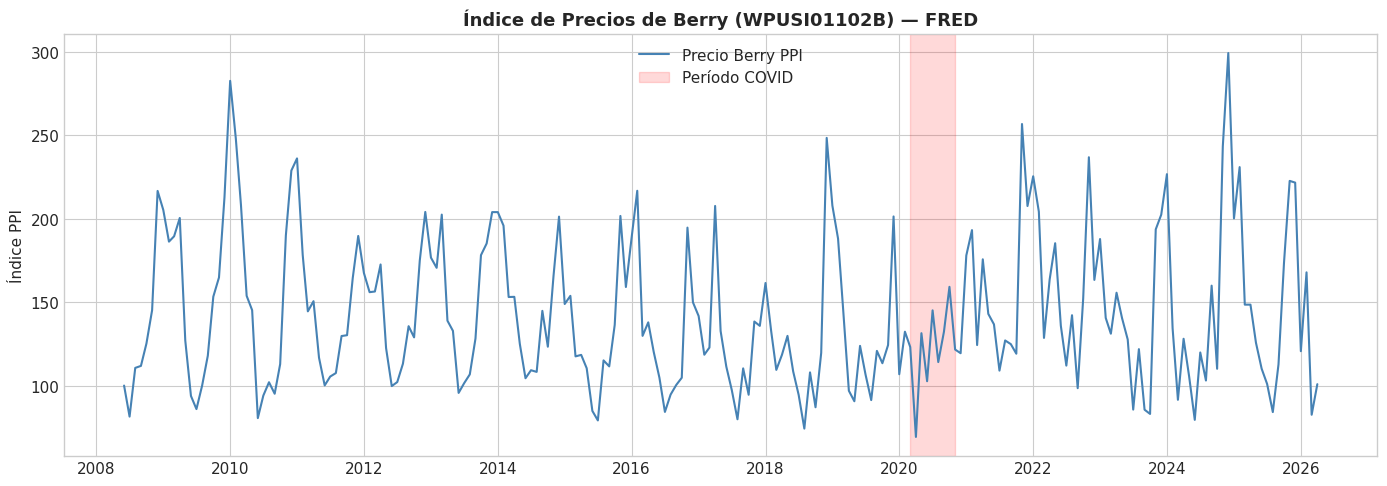

In [15]:
# Visualización inicial
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['price'], color='steelblue', linewidth=1.5, label='Precio Berry PPI')

# Sombrear período COVID
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-10-31'),
           alpha=0.15, color='red', label='Período COVID')

ax.set_title('Índice de Precios de Berry (WPUSI01102B) — FRED', fontsize=13, fontweight='bold')
ax.set_ylabel('Índice PPI')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Definir splits de entrenamiento y prueba

Evaluaremos el pronóstico para **2022-2024** (post-COVID), entrenando con datos hasta 2021.

In [16]:
TRAIN_END = '2021-12-01'
TEST_START = '2022-01-01'

# Período COVID para marcar / excluir
COVID_START = '2020-03-01'
COVID_END = '2020-10-01'

train = df[:TRAIN_END].copy()
test = df[TEST_START:].copy()

print(f'Train: {len(train)} obs ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test:  {len(test)} obs ({test.index[0].date()} → {test.index[-1].date()})')

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = {}  # almacenaremos métricas aquí

Train: 163 obs (2008-06-01 → 2021-12-01)
Test:  52 obs (2022-01-01 → 2026-04-01)


---
## Técnica 1: Baseline — Suavizado Exponencial (sin corrección)

> **Idea**: Ignorar el shock y entrenar con todos los datos tal cual.
>
> **Problema**: El modelo aprende el spike de COVID como si fuera información válida sobre patrones futuros.

In [17]:
model_base = ExponentialSmoothing(
    train['price'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

forecast_base = model_base.forecast(len(test))
forecast_base.index = test.index

results['Baseline (sin corrección)'] = {
    'MAE': mean_absolute_error(test['price'], forecast_base),
    'RMSE': rmse(test['price'], forecast_base)
}

print('✅ Baseline entrenado')
print(f"  MAE: {results['Baseline (sin corrección)']['MAE']:.2f}")
print(f"  RMSE: {results['Baseline (sin corrección)']['RMSE']:.2f}")

✅ Baseline entrenado
  MAE: 30.61
  RMSE: 38.07


---
## Técnica 2: Variable Dummy de Intervención

> **Idea**: Agregar una variable binaria (0/1) que le dice al modelo cuándo ocurrió el evento atípico.  
> El modelo aprende el *efecto* del shock y lo separa de los patrones normales.
>
> **Ventaja**: El modelo aún usa todos los datos, pero "aísla" el período anómalo.  
> **Limitación**: Necesitas saber a priori cuándo ocurrió el shock.

In [18]:
# Crear dummy de COVID en los datos de entrenamiento
train_dummy = train.copy()
train_dummy['covid'] = (
    (train_dummy.index >= COVID_START) &
    (train_dummy.index <= COVID_END)
).astype(int)

# En el test, el dummy es 0 (período post-COVID normal)
test_dummy = test.copy()
test_dummy['covid'] = 0

# SARIMAX con la dummy como exógena
model_dummy = SARIMAX(
    train_dummy['price'],
    exog=train_dummy[['covid']],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12)
).fit(disp=False)

forecast_dummy = model_dummy.forecast(
    steps=len(test),
    exog=test_dummy[['covid']]
)
forecast_dummy.index = test.index

results['SARIMAX + Dummy COVID'] = {
    'MAE': mean_absolute_error(test['price'], forecast_dummy),
    'RMSE': rmse(test['price'], forecast_dummy)
}
print('✅ Modelo con dummy de intervención entrenado')
print(f"  MAE: {results['SARIMAX + Dummy COVID']['MAE']:.2f}")
print(f"  RMSE: {results['SARIMAX + Dummy COVID']['RMSE']:.2f}")

✅ Modelo con dummy de intervención entrenado
  MAE: 30.50
  RMSE: 38.47


---
## Técnica 3: Winsorización / Imputación del período atípico

> **Idea**: Reemplazar los valores durante el shock con estimaciones más "normales" (ej. interpolación lineal, mediana, etc.) antes de entrenar.
>
> **Ventaja**: Simple, funciona con cualquier modelo.  
> **Limitación**: Se pierde información real; requiere criterio subjetivo sobre qué es "atípico".

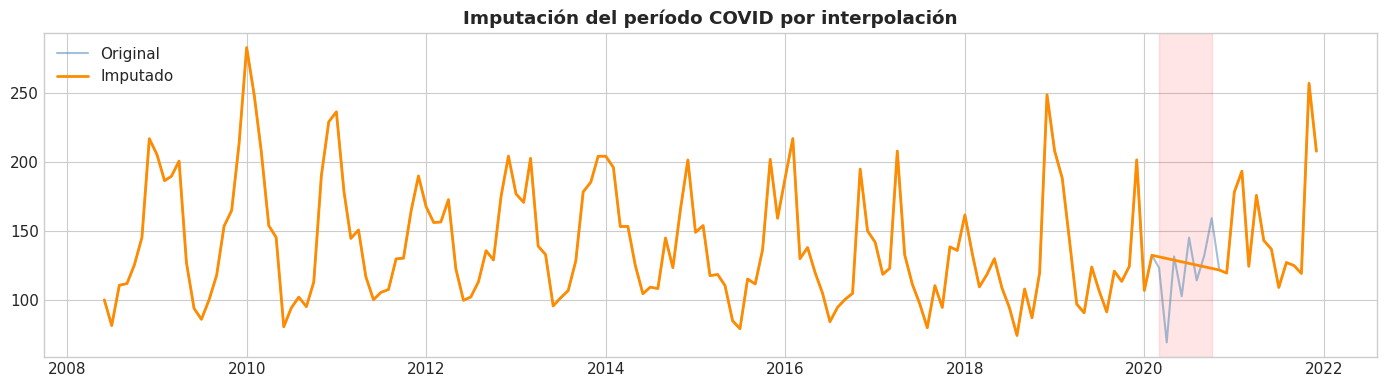

✅ Modelo con imputación entrenado
  MAE: 31.11
  RMSE: 38.54


In [19]:
train_interp = train.copy()

# Poner NaN en el período COVID y luego interpolar
mask_covid = (train_interp.index >= COVID_START) & (train_interp.index <= COVID_END)
train_interp.loc[mask_covid, 'price'] = np.nan
train_interp['price'] = train_interp['price'].interpolate(method='time')

# Visualizar la imputación
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['price'], label='Original', color='steelblue', alpha=0.5)
ax.plot(train_interp.index, train_interp['price'], label='Imputado', color='darkorange', linewidth=2)
ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), alpha=0.1, color='red')
ax.set_title('Imputación del período COVID por interpolación', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Entrenar modelo sobre datos imputados
model_interp = ExponentialSmoothing(
    train_interp['price'],
    trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

forecast_interp = model_interp.forecast(len(test))
forecast_interp.index = test.index

results['ETS + Imputación COVID'] = {
    'MAE': mean_absolute_error(test['price'], forecast_interp),
    'RMSE': rmse(test['price'], forecast_interp)
}
print('✅ Modelo con imputación entrenado')
print(f"  MAE: {results['ETS + Imputación COVID']['MAE']:.2f}")
print(f"  RMSE: {results['ETS + Imputación COVID']['RMSE']:.2f}")

---
## Técnica 4: Exclusión del período atípico

> **Idea**: Simplemente no incluir el período COVID en el entrenamiento.
>
> **Ventaja**: El modelo nunca "ve" el shock, por lo que no puede aprenderlo.  
> **Limitación**: Rompe la continuidad de la serie; algunos modelos asumen equi-espaciamiento.

In [20]:
# Excluir meses COVID del entrenamiento
mask_exclude = (train.index >= COVID_START) & (train.index <= COVID_END)
train_excl = train[~mask_exclude].copy()

print(f'Train original: {len(train)} obs')
print(f'Train sin COVID: {len(train_excl)} obs ({len(train)-len(train_excl)} excluidos)')

# Nota: al excluir datos, debemos re-indexar para que ETS funcione bien
# Usamos interpolación del índice para mantener frecuencia mensual
train_excl_reindexed = train_excl.reindex(
    pd.date_range(train_excl.index[0], train_excl.index[-1], freq='MS')
).interpolate(method='time')

model_excl = ExponentialSmoothing(
    train_excl_reindexed['price'],
    trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

forecast_excl = model_excl.forecast(len(test))
forecast_excl.index = test.index

results['ETS + Exclusión COVID'] = {
    'MAE': mean_absolute_error(test['price'], forecast_excl),
    'RMSE': rmse(test['price'], forecast_excl)
}
print('✅ Modelo con exclusión entrenado')
print(f"  MAE: {results['ETS + Exclusión COVID']['MAE']:.2f}")
print(f"  RMSE: {results['ETS + Exclusión COVID']['RMSE']:.2f}")

Train original: 163 obs
Train sin COVID: 155 obs (8 excluidos)
✅ Modelo con exclusión entrenado
  MAE: 31.11
  RMSE: 38.54


---
## Técnica 5: Isolation Forest — Detección Automática de Anomalías

> **Idea**: Usar un algoritmo no supervisado (Isolation Forest) para detectar automáticamente qué observaciones son anómalas, sin necesidad de etiquetar manualmente el período COVID.
>
> **Ventaja**: No requiere conocimiento previo del shock.  
> **Limitación**: Puede marcar falsas anomalías; la contaminación (`contamination`) es un hiperparámetro sensible.

Anomalías detectadas: 13 (8.0%)
Fechas anómalas detectadas:
[Timestamp('2010-01-01 00:00:00'), Timestamp('2010-02-01 00:00:00'), Timestamp('2010-03-01 00:00:00'), Timestamp('2010-12-01 00:00:00'), Timestamp('2011-01-01 00:00:00'), Timestamp('2011-02-01 00:00:00'), Timestamp('2012-01-01 00:00:00'), Timestamp('2018-12-01 00:00:00'), Timestamp('2019-12-01 00:00:00'), Timestamp('2020-01-01 00:00:00'), Timestamp('2020-05-01 00:00:00'), Timestamp('2021-11-01 00:00:00'), Timestamp('2021-12-01 00:00:00')]


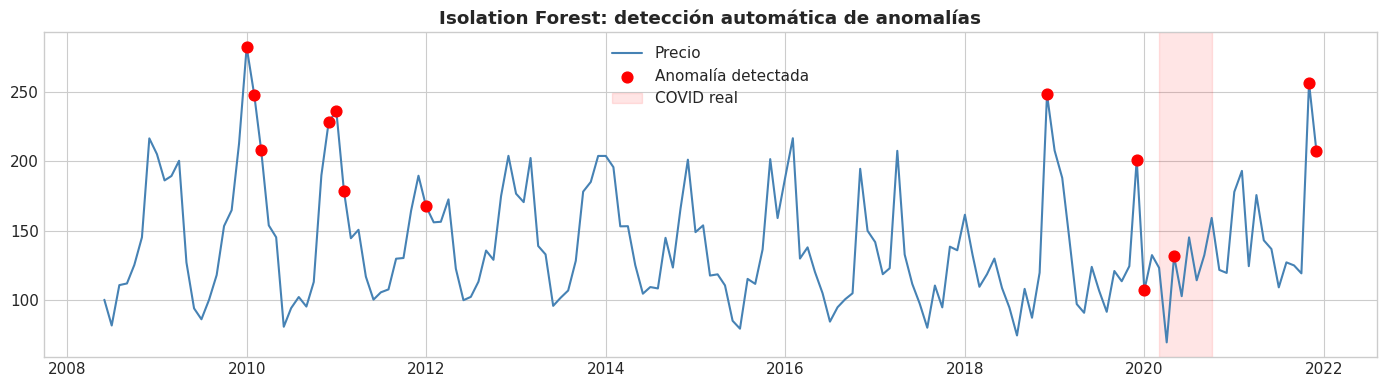


  MAE: 34.03
  RMSE: 45.63


In [21]:
# Construir features para el detector de anomalías
train_feat = train.copy()
train_feat['month'] = train_feat.index.month
train_feat['t'] = np.arange(len(train_feat))  # tendencia lineal
train_feat['lag1'] = train_feat['price'].shift(1).bfill()
train_feat['lag12'] = train_feat['price'].shift(12).bfill()

iso = IsolationForest(contamination=0.08, random_state=42)
anomaly_labels = iso.fit_predict(train_feat[['price', 'lag1', 'lag12', 'month']])

is_anomaly = anomaly_labels == -1
print(f'Anomalías detectadas: {is_anomaly.sum()} ({is_anomaly.mean()*100:.1f}%)')
print('Fechas anómalas detectadas:')
print(train_feat[is_anomaly].index.tolist())

# Visualizar
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['price'], color='steelblue', label='Precio', linewidth=1.5)
ax.scatter(train_feat[is_anomaly].index, train_feat[is_anomaly]['price'],
           color='red', zorder=5, s=60, label='Anomalía detectada')
ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), alpha=0.1, color='red', label='COVID real')
ax.set_title('Isolation Forest: detección automática de anomalías', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Imputar anomalías detectadas y reentrenar
train_iso_clean = train.copy()
train_iso_clean.loc[is_anomaly, 'price'] = np.nan
train_iso_clean['price'] = train_iso_clean['price'].interpolate(method='time')

model_iso = ExponentialSmoothing(
    train_iso_clean['price'],
    trend='add', seasonal='add', seasonal_periods=12
).fit(optimized=True)

forecast_iso = model_iso.forecast(len(test))
forecast_iso.index = test.index

results['Isolation Forest + ETS'] = {
    'MAE': mean_absolute_error(test['price'], forecast_iso),
    'RMSE': rmse(test['price'], forecast_iso)
}
print(f"\n  MAE: {results['Isolation Forest + ETS']['MAE']:.2f}")
print(f"  RMSE: {results['Isolation Forest + ETS']['RMSE']:.2f}")

---
## Técnica 6 (Bonus): Prophet con Changepoints

> **Idea**: Meta's Prophet detecta automáticamente quiebres estructurales en la tendencia y puede recibir "holidays" o fechas de eventos especiales.
>
> **Ventaja**: Muy robusto a cambios de tendencia; API simple.  
> **Limitación**: Requiere instalación extra; puede sobre-suavizar.

In [22]:
try:
    from prophet import Prophet

    # Prophet requiere columnas 'ds' y 'y'
    # reset_index() puede producir 'DATE', 'observation_date' u otro nombre según el CSV
    df_prophet = train.reset_index()
    df_prophet.columns = ['ds', 'y']  # renombrar sin importar cómo se llame el índice

    # Definir el shock COVID como un "holiday" / evento especial
    covid_event = pd.DataFrame({
        'holiday': 'covid_shock',
        'ds': pd.date_range(COVID_START, COVID_END, freq='MS'),
        'lower_window': 0,
        'upper_window': 0
    })

    model_prophet = Prophet(
        holidays=covid_event,
        seasonality_mode='additive',
        yearly_seasonality=True,
        changepoint_prior_scale=0.1  # qué tan flexible es la tendencia
    )
    model_prophet.fit(df_prophet)

    future = model_prophet.make_future_dataframe(periods=len(test), freq='MS')
    forecast_prophet_df = model_prophet.predict(future)
    forecast_prophet = forecast_prophet_df.set_index('ds')['yhat'][-len(test):]
    forecast_prophet.index = test.index

    results['Prophet + COVID holiday'] = {
        'MAE': mean_absolute_error(test['price'], forecast_prophet),
        'RMSE': rmse(test['price'], forecast_prophet)
    }
    print('✅ Prophet entrenado')
    print(f"  MAE: {results['Prophet + COVID holiday']['MAE']:.2f}")
    print(f"  RMSE: {results['Prophet + COVID holiday']['RMSE']:.2f}")
    prophet_available = True

except (ImportError, Exception) as e:
    if 'prophet' in str(type(e).__module__):
        print(f'❌ Error en Prophet: {e}')
    else:
        print('⚠️ Prophet no instalado. Ejecuta: pip install prophet')
    print('   Omitiendo esta técnica...')
    prophet_available = False

13:33:33 - cmdstanpy - INFO - Chain [1] start processing


13:33:33 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet entrenado
  MAE: 30.94
  RMSE: 37.95


---
## Comparación Visual de Pronósticos

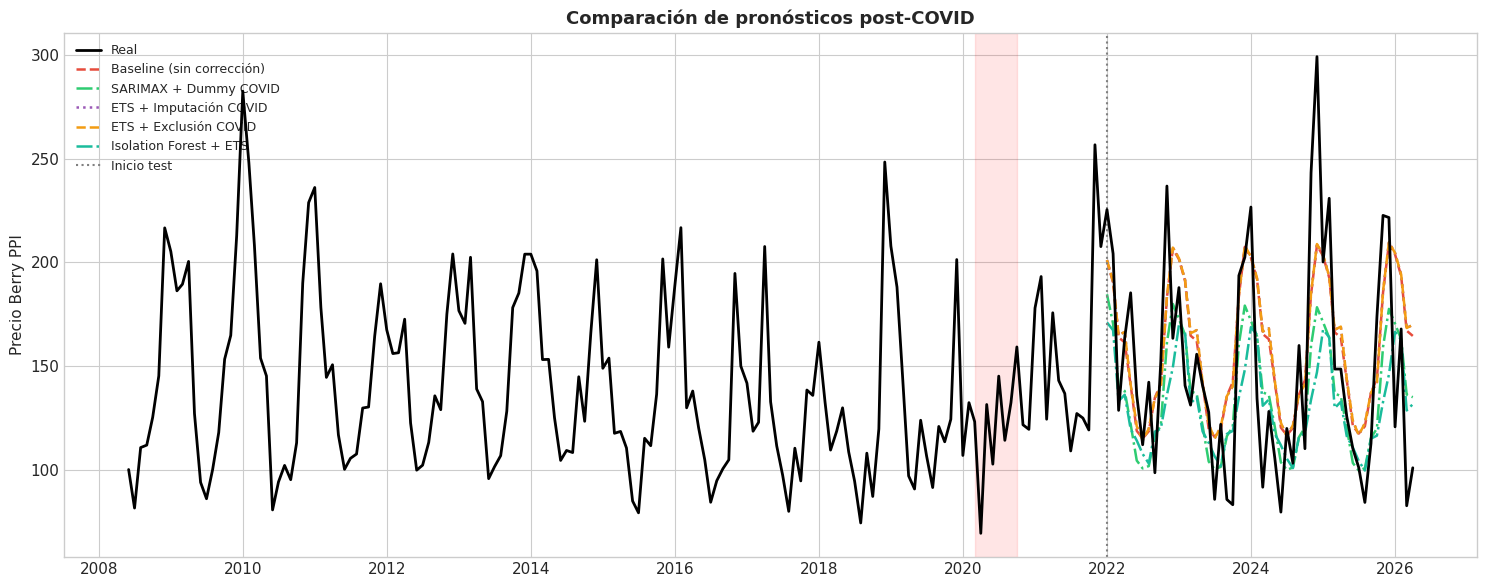

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))

# Datos reales
ax.plot(df.index, df['price'], color='black', linewidth=2, label='Real', zorder=10)

# Pronósticos
colores = ['#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
estilos = ['--', '-.', ':', '--', '-.']

for (nombre, _), color, estilo in zip(results.items(), colores, estilos):
    if nombre == 'Baseline (sin corrección)':
        ax.plot(test.index, forecast_base, color=color, linestyle=estilo, label=nombre, linewidth=1.8)
    elif nombre == 'SARIMAX + Dummy COVID':
        ax.plot(test.index, forecast_dummy, color=color, linestyle=estilo, label=nombre, linewidth=1.8)
    elif nombre == 'ETS + Imputación COVID':
        ax.plot(test.index, forecast_interp, color=color, linestyle=estilo, label=nombre, linewidth=1.8)
    elif nombre == 'ETS + Exclusión COVID':
        ax.plot(test.index, forecast_excl, color=color, linestyle=estilo, label=nombre, linewidth=1.8)
    elif nombre == 'Isolation Forest + ETS':
        ax.plot(test.index, forecast_iso, color=color, linestyle=estilo, label=nombre, linewidth=1.8)

ax.axvspan(pd.Timestamp(COVID_START), pd.Timestamp(COVID_END), alpha=0.1, color='red')
ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.5, label='Inicio test')
ax.set_title('Comparación de pronósticos post-COVID', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio Berry PPI')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## Tabla de Métricas Finales

=== RESUMEN DE MÉTRICAS ===
                             MAE   RMSE  Mejora vs Baseline (RMSE %)
Prophet + COVID holiday    30.94  37.95                          0.3
Baseline (sin corrección)  30.61  38.07                         -0.0
SARIMAX + Dummy COVID      30.50  38.47                         -1.1
ETS + Imputación COVID     31.11  38.54                         -1.2
ETS + Exclusión COVID      31.11  38.54                         -1.2
Isolation Forest + ETS     34.03  45.63                        -19.9


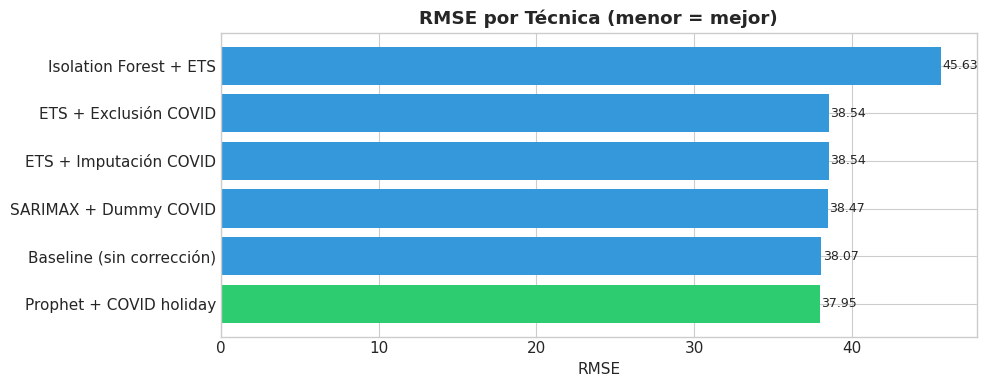

In [24]:
df_results = pd.DataFrame(results).T.round(2)
df_results = df_results.sort_values('RMSE')
df_results['Mejora vs Baseline (RMSE %)'] = (
    (results['Baseline (sin corrección)']['RMSE'] - df_results['RMSE']) /
    results['Baseline (sin corrección)']['RMSE'] * 100
).round(1)

print('=== RESUMEN DE MÉTRICAS ===')
print(df_results.to_string())

# Gráfico de barras de RMSE
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_results.index, df_results['RMSE'],
               color=['#2ecc71' if i==0 else '#3498db' for i in range(len(df_results))])
ax.set_xlabel('RMSE')
ax.set_title('RMSE por Técnica (menor = mejor)', fontweight='bold')
for bar, val in zip(bars, df_results['RMSE']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 📋 Resumen de Técnicas

| Técnica | Requiere conocer el shock | Complejidad | Cuándo usar |
|---------|--------------------------|-------------|-------------|
| **Baseline** | — | Baja | Referencia para comparar |
| **Dummy de intervención** | ✅ Sí | Baja-Media | Cuando el shock es bien conocido y datado |
| **Imputación/Winsorización** | ✅ Sí | Baja | Corrección simple, cualquier modelo downstream |
| **Exclusión del período** | ✅ Sí | Media | Shocks muy extremos o cortos |
| **Isolation Forest** | ❌ No | Media | Cuando no sabes exactamente cuándo ni qué fue el shock |
| **Prophet + holidays** | ✅ Sí | Media | Series con múltiples quiebres + estacionalidad compleja |

### Recomendaciones prácticas para datos de precios de commodities agrícolas:
1. **Si el shock está bien documentado** → usa dummy de intervención (ARIMAX/SARIMAX)
2. **Si quieres automatización** → Isolation Forest primero, luego imputa
3. **Si tienes múltiples shocks históricos** → Prophet maneja esto muy bien
4. **Siempre valida** que tus correcciones no distorsionen la varianza natural del mercado